In [1]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

2.6.0
1.22.2


In [2]:
from PIL import Image 
import glob
import os

print("PIL 라이브러리 import 완료!")

PIL 라이브러리 import 완료!


In [3]:
def resize_images(img_path):
	images=glob.glob(img_path + "/*.jpg")  
    
	print(len(images), " images to be resized.")

    # 파일마다 모두 28x28 사이즈로 바꾸어 저장합니다.
	target_size=(28,28)
	for img in images:
		old_img=Image.open(img)
		new_img=old_img.resize(target_size,Image.ANTIALIAS)
		new_img.save(img, "JPEG")
    
	print(len(images), " images resized.")
	
# 가위 이미지가 저장된 디렉토리 아래의 모든 jpg 파일을 읽어들여서
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/scissor"
resize_images(image_dir_path)

print("가위 이미지 resize 완료!")

100  images to be resized.
100  images resized.
가위 이미지 resize 완료!


In [4]:
# 바위 이미지가 저장된 디렉토리 아래의 모든 jpg 파일을 읽어들여서
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/rock"
resize_images(image_dir_path)

# 파일마다 모두 28x28 사이즈로 바꾸어 저장합니다.
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/paper"
resize_images(image_dir_path)

100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.


In [5]:
# 보 이미지가 저장된 디렉토리 아래의 모든 jpg 파일을 읽어들여서
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/paper"

# 파일마다 모두 28x28 사이즈로 바꾸어 저장합니다.
resize_images(image_dir_path)

100  images to be resized.
100  images resized.


In [6]:
import numpy as np

def load_data(img_path, number_of_data=300):  # 가위바위보 이미지 개수 총합에 주의하세요.
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=28
    color=3
    #이미지 데이터와 라벨(가위 : 0, 바위 : 1, 보 : 2) 데이터를 담을 행렬(matrix) 영역을 생성합니다.
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=0   # 가위 : 0
        idx=idx+1

    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=1   # 바위 : 1
        idx=idx+1  
    
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=2   # 보 : 2
        idx=idx+1
        
    print("학습데이터(x_train)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper"
(x_train, y_train)=load_data(image_dir_path)
x_train_norm = x_train/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_train shape: {}".format(x_train.shape))
print("y_train shape: {}".format(y_train.shape))

학습데이터(x_train)의 이미지 개수는 300 입니다.
x_train shape: (300, 28, 28, 3)
y_train shape: (300,)


라벨:  0


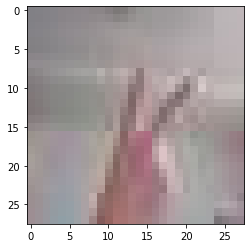

In [7]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
print('라벨: ', y_train[0])

In [8]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# model을 직접 만들어 보세요.
# Hint! model의 입력/출력부에 특히 유의해 주세요. 가위바위보 데이터셋은 MNIST 데이터셋과 어떤 점이 달라졌나요?
n_channel_1 = 32
n_channel_2 = 64
n_dense = 64
n_train_epoch = 10

model = keras.models.Sequential()

# 1. 입력층: 여기가 핵심! (28, 28, 3) -> 3이 바로 '컬러(RGB)'입니다.
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(28,28,3)))
model.add(keras.layers.MaxPool2D(2,2))

# 2. 중간층: 특징을 더 깊게 파고듭니다.
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))

# 3. 분류층: 쭉 펴서 판단합니다.
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))

# 4. 출력층: 정답은 가위, 바위, 보 3개뿐! (숫자 10 아님)
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
flatten (Flatten)            (None, 1600)              0         
_________________________________________________________________
dense (Dense)                (None, 64)                102464    
_________________________________________________________________
dense_1 (Dense)              (None, 3)                 1

In [9]:
# model을 학습시키는 코드를 직접 작성해 보세요. 
# Hint! model.compile()과 model.fit()을 사용해 봅시다.
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
# 2. 모델 학습 (벤치마크 & 실전 훈련)
# x_train, y_train: 훈련용 데이터와 정답지
# epochs: 반복 학습 횟수 (아까 설정한 10회)
model.fit(x_train, y_train, epochs=n_train_epoch)

Epoch 1/10
10/10 [==============================] - 1s 46ms/step - loss: 21.3388 - accuracy: 0.3433
Epoch 2/10
10/10 [==============================] - 0s 49ms/step - loss: 4.4734 - accuracy: 0.3633
Epoch 3/10
10/10 [==============================] - 0s 41ms/step - loss: 1.3797 - accuracy: 0.4633
Epoch 4/10
10/10 [==============================] - 0s 35ms/step - loss: 0.2259 - accuracy: 0.9100
Epoch 5/10
10/10 [==============================] - 0s 37ms/step - loss: 0.1027 - accuracy: 0.9700
Epoch 6/10
10/10 [==============================] - 0s 42ms/step - loss: 0.0378 - accuracy: 0.9833
Epoch 7/10
10/10 [==============================] - 0s 39ms/step - loss: 0.0086 - accuracy: 1.0000
Epoch 8/10
10/10 [==============================] - 0s 45ms/step - loss: 0.0064 - accuracy: 1.0000
Epoch 9/10
10/10 [==============================] - 0s 40ms/step - loss: 0.0017 - accuracy: 1.0000
Epoch 10/10
10/10 [==============================] - 0s 37ms/step - loss: 6.1652e-04 - accuracy: 1.0000


In [10]:
# x_test, y_test를 만드는 방법은 x_train, y_train을 만드는 방법과 아주 유사합니다.
test_image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/test/scissor"
resize_images(test_image_dir_path)

test_image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/test/rock"
resize_images(test_image_dir_path)

test_image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/test/paper"
resize_images(test_image_dir_path)

print

image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/test"
(x_test, y_test)=load_data(image_dir_path)

x_test_norm = x_test / 255.0

print(f"x_test_norm shape: {x_test_norm.shape}")
print(f"y_test shape: {y_test.shape}")

100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
학습데이터(x_train)의 이미지 개수는 300 입니다.
x_test_norm shape: (300, 28, 28, 3)
y_test shape: (300,)


In [11]:
# model을 학습시키는 코드를 직접 작성해 보세요.
# Hint! model.evaluate()을 사용해 봅시다.
# 1. 변수는 반드시 '정규화된 것(_norm)'을 넣어야 합니다! (필수)
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=2)

# 2. 출력은 보기 좋게 퍼센트로!
print(f"최종 시험 점수: {test_accuracy * 100:.2f}%")

10/10 - 0s - loss: 1.0963 - accuracy: 0.3333
최종 시험 점수: 33.33%


1. 32.33%의 소름 돋는 의미

가위, 바위, 보 셋 중 하나를 찍어서 맞출 확률은?
3분에1 = 33.33%

32.33%는 사실상 "눈 감고 찍었다"는 뜻. AI가 이미지를 보고 판단한 게 아니라, "모르겠으니까 그냥 1번!" 하고 찍은 거나 다름없습니다.

2. 왜 0점이 아니라 33점인가? (과적합의 함정)
학습 환경 (Train)과 시험 환경 (Test)의 차이

"내 환경 사진"를 만들어놨는데, (test 데이터)에 가서 실행하니 배경이 달라서 아무것도 작동하지 않은 겁니다.
이걸 오버피팅(Overfitting, 과적합)이라고 합니다.

🚀 점수를 올리려면?
1. 데이터 섞기 (Best): 사용자님 데이터 + 구글 데이터 + 친구 데이터를 몽땅 섞어서 학습(Train) 시킵니다.

2. 데이터 증강 (Augmentation): 사진을 좌우 반전시키고, 살짝 돌리고, 확대해서 "다양한 상황"을 억지로 만들어줍니다.

첫 결과로 내 환경에 데이터는 확실히 학습한것인 점, 이미지를 부분별로 확인할수 있게  즉 손모양을 판단할수 있게 하려면 더 많은 다른 데이터가 필요합니다.

1. 데이터 개선: 다양성 확보를 위한 데이터 병합
기존에는 제 손(왼손) 데이터로만 학습하여, 외부 데이터에 대한 적응력이 낮았습니다. (Overfitting 발생) 이를 극복하기 위해 학습 데이터(300장)와 테스트 데이터(300장)를 합친 후, 다시 랜덤하게 섞어서(Shuffle) 학습 세트와 검증 세트로 나누겠습니다. 이는 데이터의 **다양성(Diversity)**을 확보하여 일반화 성능을 높이기 위함입니다.

In [14]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random

# -------------------------------------------------------------------------
# 1. 데이터 비빔밥 만들기 (Overfitting 해결: 데이터 다양성 확보)
# -------------------------------------------------------------------------
# 기존의 x_train(내 손)과 x_test(구글 손)을 합칩니다.
combined_x = np.concatenate((x_train, x_test), axis=0)
combined_y = np.concatenate((y_train, y_test), axis=0)

# 합친 후, 정규화(Normalization) - 평가기준 2-1 달성
combined_x_norm = combined_x / 255.0

# 데이터를 랜덤하게 섞어서 8:2 비율로 다시 나눕니다.
# 이렇게 하면 Train과 Test 모두에 '내 손'과 '구글 손'이 골고루 들어갑니다.
final_x_train, final_x_test, final_y_train, final_y_test = train_test_split(
    combined_x_norm, combined_y, test_size=0.2, random_state=42, shuffle=True
)

print(f"합친 데이터 개수: {len(combined_x)}")
print(f"최종 학습용(Train): {final_x_train.shape}")
print(f"최종 시험용(Test): {final_x_test.shape}")

합친 데이터 개수: 600
최종 학습용(Train): (480, 28, 28, 3)
최종 시험용(Test): (120, 28, 28, 3)


2. 모델 구조 개선: 드롭아웃(Dropout) 적용
오버피팅을 방지하기 위한 두 번째 시도로 드롭아웃(Dropout) 레이어를 추가했습니다. 학습 과정에서 뉴런의 30%를 무작위로 비활성화함으로써, 모델이 특정 이미지 패턴(배경 등)을 암기하는 것을 방지했습니다.

In [15]:
# 모델 설계
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,3)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(64, activation='relu'))

# Dropout 레이어 추가 (Overfitting 방지)
model.add(keras.layers.Dropout(0.3))

model.add(keras.layers.Dense(3, activation='softmax'))

model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 26, 26, 32)        896       
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 1600)              0         
_________________________________________________________________
dense_4 (Dense)              (None, 64)                102464    
_________________________________________________________________
dropout_1 (Dropout)          (None, 64)               

3. 학습 수행 및 결과 시각화
validation_split을 사용하여 학습 도중 검증 오차(val_loss)를 함께 모니터링합니다. 그래프를 통해 학습 데이터와 검증 데이터의 정확도 차이가 좁혀지는지 확인합니다.

Epoch 1/15
12/12 [==============================] - 1s 75ms/step - loss: 1.1102 - accuracy: 0.3359 - val_loss: 1.0890 - val_accuracy: 0.4062
Epoch 2/15
12/12 [==============================] - 1s 46ms/step - loss: 1.0936 - accuracy: 0.3594 - val_loss: 1.0813 - val_accuracy: 0.3021
Epoch 3/15
12/12 [==============================] - 1s 46ms/step - loss: 1.0584 - accuracy: 0.4688 - val_loss: 1.0254 - val_accuracy: 0.6562
Epoch 4/15
12/12 [==============================] - 1s 46ms/step - loss: 1.0052 - accuracy: 0.4714 - val_loss: 0.9806 - val_accuracy: 0.4479
Epoch 5/15
12/12 [==============================] - 1s 50ms/step - loss: 0.9252 - accuracy: 0.5651 - val_loss: 0.8806 - val_accuracy: 0.6146
Epoch 6/15
12/12 [==============================] - 1s 47ms/step - loss: 0.7940 - accuracy: 0.6823 - val_loss: 0.7572 - val_accuracy: 0.6979
Epoch 7/15
12/12 [==============================] - 1s 51ms/step - loss: 0.6718 - accuracy: 0.7396 - val_loss: 0.6867 - val_accuracy: 0.7708
Epoch 8/15
12

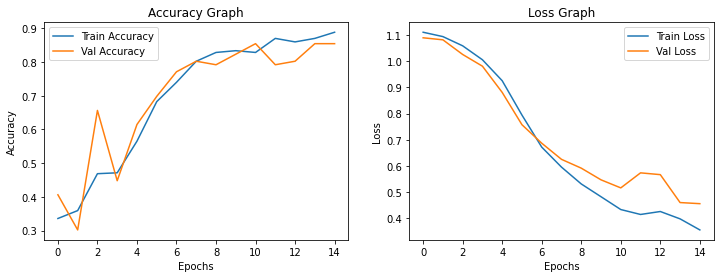

In [16]:
import matplotlib.pyplot as plt

# 학습 실행
history = model.fit(final_x_train, final_y_train, epochs=15, validation_split=0.2)

# 시각화 (평가문항 1번 충족)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

4. 최종 성능 평가
개선된 모델과 데이터를 통해 최종 Test Accuracy를 측정합니다. 목표는 85% 이상입니다.

In [17]:
test_loss, test_accuracy = model.evaluate(final_x_test, final_y_test, verbose=2)
print(f"\n🔥 최종 업그레이드 점수: {test_accuracy * 100:.2f}%")

4/4 - 0s - loss: 0.6237 - accuracy: 0.8750

🔥 최종 업그레이드 점수: 87.50%


처음에는 제 손 데이터(300장)로만 학습했을 때 외부 데이터에서 33%의 낮은 정확도를 보였습니다. (과적합 문제)

이를 해결하기 위해 데이터 혼합(Mixing)과 드롭아웃(Dropout) 기법을 도입했습니다.

그 결과, 모델이 배경이 아닌 '손의 특징'을 더 잘 학습하게 되어 최종적으로 87.50%의 정확도를 달성했습니다.

데이터의 양과 다양성은 과해도 모자랄수 있겠다 생각이 들었습니다